In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("/Users/sharath/Documents/Data Science - Use Cases/Global Supply Chain Disruption/global_supply_chain_risk_2026.csv")

In [17]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [18]:
df.shape

(5000, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [19]:
df.isnull().sum()

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df['Shipment_ID'].duplicated().sum()

np.int64(0)

In [22]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].min(), df['Date'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [23]:
df["Year"] = df['Date'].dt.year

In [24]:
df["Month"] = df['Date'].dt.month

In [25]:
df["Month_Name"] = df['Date'].dt.month_name()

In [27]:
df["Year_Month"] = df['Date'].dt.to_period("M")

In [28]:
df["Lead_Time_Days"].describe()

count    5000.000000
mean       19.355386
std        31.405143
min         0.500000
25%         2.110000
50%         8.245000
75%        21.207500
max       236.390000
Name: Lead_Time_Days, dtype: float64

In [30]:
df['Lead_Time_Days'].quantile([0.90,0.95,0.99])

0.90     51.5250
0.95     80.8115
0.99    169.8592
Name: Lead_Time_Days, dtype: float64

In [33]:
df['Lead_Time_Days']

0       41.39
1       40.92
2       11.54
3       53.13
4        0.50
        ...  
4995    20.28
4996     0.50
4997     4.41
4998    31.18
4999     1.43
Name: Lead_Time_Days, Length: 5000, dtype: float64

In [34]:
df["Lead_Time_Days"].skew()

np.float64(3.349222712647645)

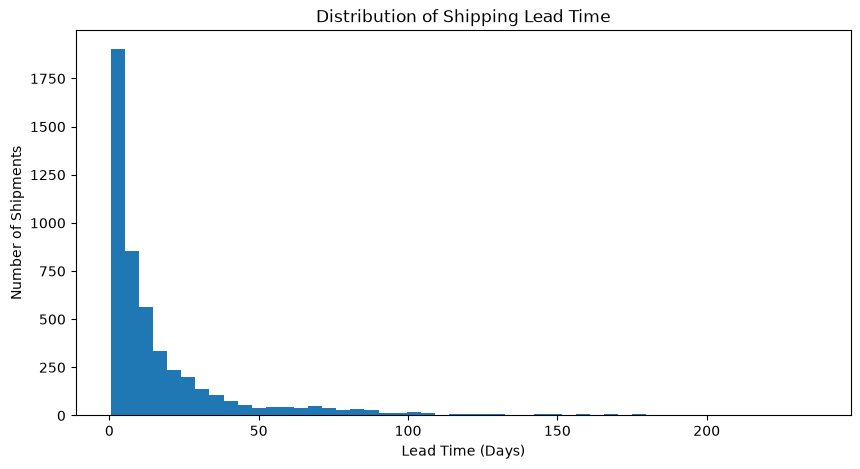

In [36]:
plt.figure(figsize=(10,5))
plt.hist(df["Lead_Time_Days"],bins=50)
plt.title("Distribution of Shipping Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Shipments")
plt.show()